In [7]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
from sklearn.model_selection import KFold, cross_val_predict
import os
from sklearn.preprocessing import LabelEncoder

ignorewarnings = True

In [2]:
df = pd.read_excel('../data_final_semua.xlsx')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   plant         1210 non-null   int64         
 1   day           1210 non-null   int64         
 2   leaf_count    1210 non-null   int64         
 3   plant_height  1210 non-null   float64       
 4   leaf_length   1210 non-null   float64       
 5   leaf_width    1210 non-null   float64       
 6   date          1210 non-null   datetime64[ns]
 7   ph            1210 non-null   float64       
 8   ppm           1210 non-null   float64       
 9   water_temp    1210 non-null   float64       
 10  air_temp      1210 non-null   float64       
 11  humidity      1210 non-null   float64       
 12  plant_type    1210 non-null   object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 123.0+ KB


In [4]:
def categorize_ppm(value):
    if value < 950:
        return "Very Low"
    elif value < 1050:
        return "Low"
    elif value < 1150:
        return "Medium"
    else:
        return "High"

df['ppm_category'] = df['ppm'].apply(categorize_ppm)

In [5]:
print(df[['ppm', 'ppm_category']].head(10))

          ppm ppm_category
0  888.677043     Very Low
1  888.677043     Very Low
2  888.677043     Very Low
3  888.677043     Very Low
4  888.677043     Very Low
5  888.677043     Very Low
6  888.677043     Very Low
7  888.677043     Very Low
8  888.677043     Very Low
9  888.677043     Very Low


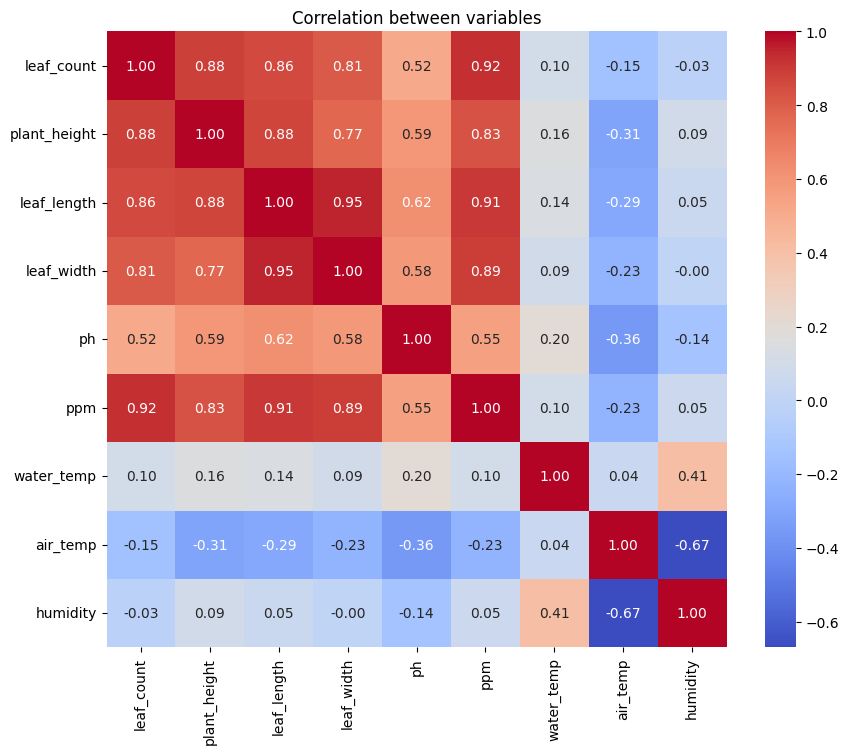

In [6]:
corr = df[['leaf_count','plant_height','leaf_length','leaf_width','ph','ppm','water_temp','air_temp','humidity']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between variables')
plt.show()

In [8]:
le = LabelEncoder()
df['plant_type'] = le.fit_transform(df['plant_type'])

In [9]:
print("\nMapping kategori -> angka:")
for i, cls in enumerate(le.classes_):
    print(f"{cls} -> {i}")


Mapping kategori -> angka:
Lettuce -> 0
Pak Choi -> 1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   plant         1210 non-null   int64         
 1   day           1210 non-null   int64         
 2   leaf_count    1210 non-null   int64         
 3   plant_height  1210 non-null   float64       
 4   leaf_length   1210 non-null   float64       
 5   leaf_width    1210 non-null   float64       
 6   date          1210 non-null   datetime64[ns]
 7   ph            1210 non-null   float64       
 8   ppm           1210 non-null   float64       
 9   water_temp    1210 non-null   float64       
 10  air_temp      1210 non-null   float64       
 11  humidity      1210 non-null   float64       
 12  plant_type    1210 non-null   int32         
 13  ppm_category  1210 non-null   object        
dtypes: datetime64[ns](1), float64(8), int32(1), int64(3), object(1)
memory usage: 127.7+ KB


### Semua sensor + tanaman

In [11]:
X = df[['ph', 'water_temp', 'air_temp', 'humidity',
        'leaf_count', 'plant_height', 'leaf_length', 'leaf_width', 'plant_type']]

y = df['ppm']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [15]:
y_pred = model.predict(X_test_scaled)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

MAE: 1.1770413178742793
R2 : 0.9891102498118569


        Feature    Importance
4    leaf_count  7.351494e-01
0            ph  1.256698e-01
6   leaf_length  6.896820e-02
7    leaf_width  3.647083e-02
2      air_temp  1.248006e-02
1    water_temp  1.127643e-02
3      humidity  9.984967e-03
5  plant_height  3.220101e-07
8    plant_type  1.923789e-15


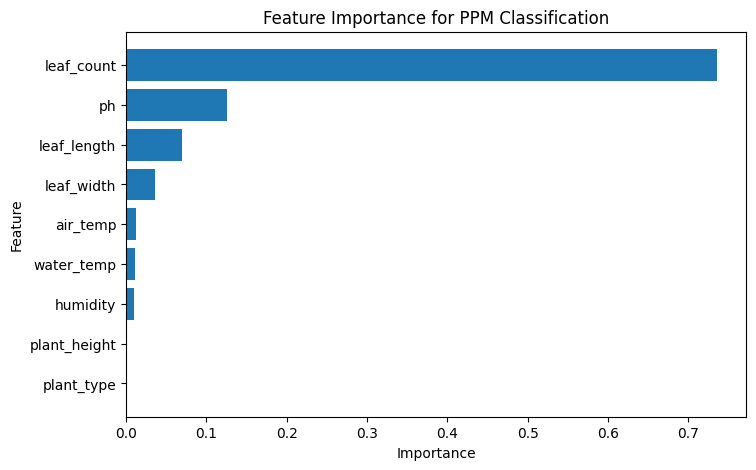

In [16]:
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Tampilkan 10 fitur paling penting
print(feature_importance)

# Visualisasi
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PPM Classification')
plt.gca().invert_yaxis()
plt.show()

In [17]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [18]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res_mae = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_res_r2 = cross_val_score(pipeline, X, y, cv=cv, scoring='r2', n_jobs=-1)
print(f"CV MAE: {-cv_res_mae.mean():.4f} ± {cv_res_mae.std():.4f}")
print(f"CV R2 : {cv_res_r2.mean():.4f} ± {cv_res_r2.std():.4f}")

CV MAE: 1.8695 ± 0.5815
CV R2 : 0.9920 ± 0.0083


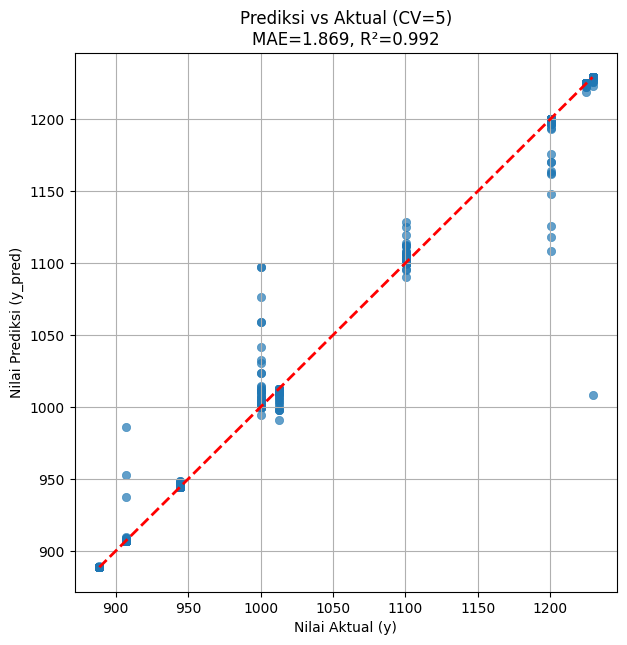

In [19]:
y_pred_cv = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)

mae = mean_absolute_error(y, y_pred_cv)
r2 = r2_score(y, y_pred_cv)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y, y=y_pred_cv, alpha=0.7, edgecolor=None)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Nilai Aktual (y)")
plt.ylabel("Nilai Prediksi (y_pred)")
plt.title(f"Prediksi vs Aktual (CV=5)\nMAE={mae:.3f}, R²={r2:.3f}")
plt.grid(True)
plt.show()

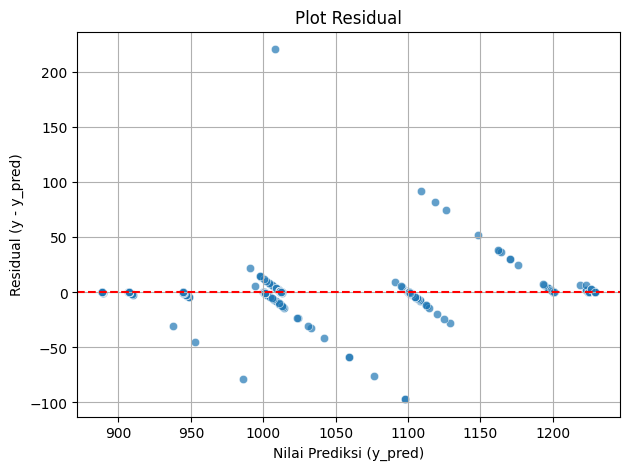

In [20]:
residuals = y - y_pred_cv
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_cv, y=residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Nilai Prediksi (y_pred)")
plt.ylabel("Residual (y - y_pred)")
plt.title("Plot Residual")
plt.grid(True)
plt.show()

### Hanya Sensor

In [31]:
X2 = df[['ph', 'water_temp', 'air_temp', 'humidity', 'plant_type']]

y2 = df['ppm']

In [32]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

In [33]:
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

In [34]:
model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train2_scaled, y_train2)

RandomForestRegressor(random_state=42)

In [35]:
y_pred2 = model2.predict(X_test2_scaled)
print("MAE:", mean_absolute_error(y_test2, y_pred2))
print("R2 :", r2_score(y_test2, y_pred2))

MAE: 1.3194563287084526e-12
R2 : 1.0


      Feature    Importance
0          ph  5.258271e-01
2    air_temp  4.138935e-01
1  water_temp  4.241237e-02
3    humidity  1.786697e-02
4  plant_type  3.367962e-14


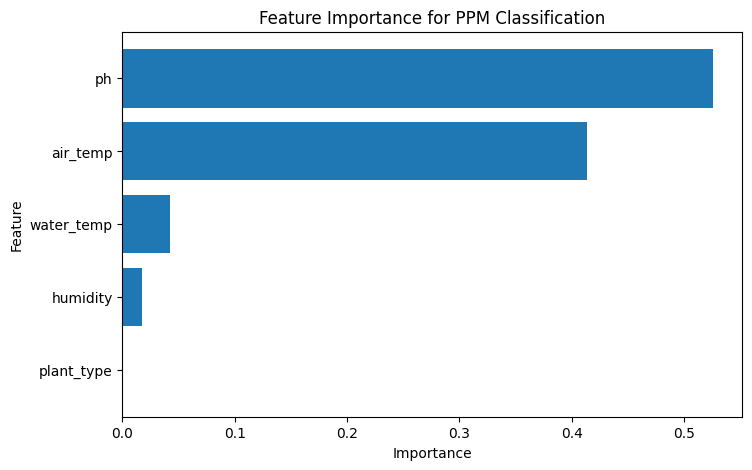

In [36]:
importance2 = model2.feature_importances_
feature_importance2 = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': importance2
}).sort_values(by='Importance', ascending=False)

# Tampilkan 10 fitur paling penting
print(feature_importance2)

# Visualisasi
plt.figure(figsize=(8,5))
plt.barh(feature_importance2['Feature'], feature_importance2['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PPM Classification')
plt.gca().invert_yaxis()
plt.show()

In [37]:
pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [38]:
cv2 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res_mae2 = cross_val_score(pipeline2, X2, y2, cv=cv2, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_res_r22 = cross_val_score(pipeline2, X2, y2, cv=cv2, scoring='r2', n_jobs=-1)
print(f"CV MAE: {-cv_res_mae2.mean():.4f} ± {cv_res_mae2.std():.4f}")
print(f"CV R2 : {cv_res_r22.mean():.4f} ± {cv_res_r22.std():.4f}")

CV MAE: 0.0000 ± 0.0000
CV R2 : 1.0000 ± 0.0000


### Penggunaan Model

In [39]:
pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('reg',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=5,
                                       random_state=42))])

In [40]:
pipeline2.fit(X2, y2)

Pipeline(steps=[('scaler', StandardScaler()),
                ('reg',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=5,
                                       random_state=42))])

In [42]:
sample_reg = {
    'ph': 6.5,
    'water_temp': 22.0,
    'air_temp': 25.0,
    'humidity': 60.0,
    'leaf_count': 8,
    'plant_height': 12.5,
    'leaf_length': 6.0,
    'leaf_width': 2.5,
    'plant_type': 1
}

# Jika ingin hanya sensor:
sample_sensor = {
    'ph': 6.5,
    'water_temp': 22.0,
    'air_temp': 25.0,
    'humidity': 60.0,
    'plant_type': 1
}

In [43]:
sample_df = pd.DataFrame([sample_reg])
sample_df2 = pd.DataFrame([sample_sensor])

In [44]:
predicted_value = pipeline.predict(sample_df)[0]

print(f"Hasil prediksi untuk sample_reg: {predicted_value:.4f}")

Hasil prediksi untuk sample_reg: 1034.7310


In [45]:
predicted_value2 = pipeline2.predict(sample_df2)[0]

print(f"Hasil prediksi untuk sample_sensor: {predicted_value2:.4f}")

Hasil prediksi untuk sample_sensor: 1100.4793


In [46]:
save_dir = 'models'
os.makedirs(save_dir, exist_ok=True)

In [47]:
model_path = os.path.join(save_dir, 'model_pipeline_all.pkl')
joblib.dump(pipeline, model_path)
model_path2 = os.path.join(save_dir, 'model_pipeline_sensor.pkl')
joblib.dump(pipeline2, model_path2)

['models\\model_pipeline_sensor.pkl']